## Environment Setup and Hardware Check

In [1]:
import sys
import torch

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Compiled Version: {torch.version.cuda}")
print(f"CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 1.12.1+cu113
CUDA Compiled Version: 11.3
CUDA Available: True


In [2]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()

In [5]:
!nvidia-smi

Sun Aug  9 06:02:46 2026       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.199.02   Driver Version: 470.199.02   CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA A100-SXM...  On   | 00000000:BD:00.0 Off |                   On |
| N/A   30C    P0    46W / 400W |                  N/A |     N/A      Default |
|                               |                      |              Enabled |
+-------------------------------+----------------------+----------------------+

+-----------------------------------------------------------------------------+
| MIG d

In [8]:
import sys
import random
import logging
import psutil
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Configure notebook logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)]
)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    logging.info(f"All seeds set to {seed}")

seed_everything(42)

# Hardware Specifications
ram = psutil.virtual_memory()
logging.info(f"Total RAM: {ram.total / (1024**3):.2f} GB | Available: {ram.available / (1024**3):.2f} GB")
logging.info(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    logging.info(f"GPU Device Name: {torch.cuda.get_device_name(0)}")

2026-08-09 06:02:59,192 | INFO | All seeds set to 42
2026-08-09 06:02:59,194 | INFO | Total RAM: 1007.68 GB | Available: 930.39 GB
2026-08-09 06:02:59,195 | INFO | Is CUDA available? True
2026-08-09 06:02:59,195 | INFO | GPU Device Name: NVIDIA A100-SXM4-40GB MIG 3g.20gb


## Quadrature Grid

In [44]:
# ==========================================
# CELL 2: STATIC SPATIAL QUADRATURE & TEST FUNCTIONS
# ==========================================
import numpy as np
import torch

def get_1d_gauss_legendre(N, a=0.0, b=1.0):
    x, w = np.polynomial.legendre.leggauss(N)
    return torch.tensor(0.5 * (x + 1) * (b - a) + a, dtype=torch.float32), \
           torch.tensor(0.5 * w * (b - a), dtype=torch.float32)

def generate_stretched_y_gauss(Ny, k=6.0):
    xi, w_xi = get_1d_gauss_legendre(Ny, a=0.0, b=1.0)
    y_points = torch.tanh(k * xi) / np.tanh(k)
    dy_dxi = k / (torch.cosh(k * xi)**2 * np.tanh(k))
    return y_points, w_xi * dy_dxi

def build_spatial_quadrature(Nx, Ny, k=6.0):
    x, w_x = get_1d_gauss_legendre(Nx)
    y, w_y = generate_stretched_y_gauss(Ny, k)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    W_X, W_Y = torch.meshgrid(w_x, w_y, indexing='ij')
    return torch.stack([X.flatten(), Y.flatten()], dim=-1), (W_X * W_Y).flatten()

def build_boundary_spatial_quadrature(Nx):
    x, w_x = get_1d_gauss_legendre(Nx)
    return x.unsqueeze(1), w_x 

def generate_test_functions(points, num_modes_x=4, num_modes_y=4):
    x, y = points[:, 0], points[:, 1]
    v_list, dv_dx_list, dv_dy_list = [], [], []
    
    for m in range(1, num_modes_x + 1):
        for n in range(1, num_modes_y + 1):
            v_list.append(torch.cos(m * np.pi * x) * torch.sin(n * np.pi * y / 2.0))
            dv_dx_list.append(-m * np.pi * torch.sin(m * np.pi * x) * torch.sin(n * np.pi * y / 2.0))
            dv_dy_list.append((n * np.pi / 2.0) * torch.cos(m * np.pi * x) * torch.cos(n * np.pi * y / 2.0))
            
    return torch.stack(v_list, dim=0), \
           torch.stack([torch.stack(dv_dx_list, dim=0), torch.stack(dv_dy_list, dim=0)], dim=-1)

# Precompute Static 2D Grid
PTS_SPACE, W_SPACE = build_spatial_quadrature(Nx=15, Ny=30)
PTS_WALL_X, W_WALL_X = build_boundary_spatial_quadrature(Nx=15)

V_SPACE, GRAD_V_SPACE = generate_test_functions(PTS_SPACE)
V_WALL_X, _ = generate_test_functions(torch.cat([PTS_WALL_X, torch.ones_like(PTS_WALL_X)], dim=-1))

## Data Generator

In [45]:
import torch
import numpy as np
import logging

# ==========================================
# 1. SOIL PARAMETER INGESTION (NACE RESISTIVITY)
# ==========================================
def process_soil_parameters(rho_ohm_cm, n_electrons=2.0, C_bulk=1.0):
    """
    Converts NACE soil resistivity (rho in Ohm-cm) to conductivity (sigma in S/m)
    for hard-parameter injection into charge balance.
    """
    rho_ohm_m = rho_ohm_cm / 100.0  # Convert to Ohm-m
    sigma_S_m = 1.0 / rho_ohm_m     # Convert to Siemens/meter (S/m)
    
    return {
        "sigma": torch.tensor([sigma_S_m], dtype=torch.float32),
        "n_electrons": torch.tensor([n_electrons], dtype=torch.float32),
        "C_bulk": torch.tensor([C_bulk], dtype=torch.float32)
    }

# ==========================================
# 2. API 5L MULTI-INPUT DATA GENERATOR
# ==========================================
class API5LDataGenerator:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.wt_min, self.wt_max = 0.25, 1.0   # Wall thickness (inches)
        self.od_min, self.od_max = 4.0, 48.0   # Outer diameter (inches)

    def generate_grf_profiles(self, points, length_scale=0.2):
        """Generates 1D Gaussian Random Fields for environmental profiles."""
        x = np.linspace(0, 1, points)
        X, Y = np.meshgrid(x, x)
        covariance_matrix = np.exp(-0.5 * ((X - Y) / length_scale)**2) + 1e-6 * np.eye(points)
        L = np.linalg.cholesky(covariance_matrix)
        standard_normals = np.random.randn(self.batch_size, points)
        normalized_profiles = 1 / (1 + np.exp(-(standard_normals @ L.T)))
        return torch.tensor(normalized_profiles, dtype=torch.float32)

    def generate_api5l_metadata(self):
        """Generates normalized and raw structural metadata."""
        real_wt = torch.FloatTensor(self.batch_size).uniform_(self.wt_min, self.wt_max)
        real_od = torch.FloatTensor(self.batch_size).uniform_(self.od_min, self.od_max)
        yolo_defect_score = torch.FloatTensor(self.batch_size).uniform_(0.0, 1.0)

        norm_wt = (real_wt - self.wt_min) / (self.wt_max - self.wt_min)
        norm_od = (real_od - self.od_min) / (self.od_max - self.od_min)

        meta_tensor = torch.stack((norm_wt, norm_od, yolo_defect_score), dim=1)      
        raw_tensor  = torch.stack((real_wt, real_od, yolo_defect_score), dim=1)      
        
        return meta_tensor, raw_tensor

# Initialize Data Generator
generator = API5LDataGenerator(batch_size=1000)

soil_tensor = generator.generate_grf_profiles(points=4, length_scale=0.15)    # [1000, 4]
fluid_tensor = generator.generate_grf_profiles(points=50, length_scale=0.3)  # [1000, 50]
meta_tensor, raw_tensor = generator.generate_api5l_metadata()                  # [1000, 3]

# Default NACE Soil Parameters (1000 Ohm-cm Soil)
PHYSICS_PARAMS = {
    "D_global": 1e-9,
    "k_rate": 1e-5,
    "alpha": 0.5,
    "F": 96485.0,
    "R": 8.314,
    "T": 298.15,
    "E_eq": -0.44,
    "t_max": 31536000.0,  # 1 year in seconds
    "soil_resistivity_ohm_cm": 1000.0,
    "n_electrons": 2.0,
    "C_bulk": 1.0
}

SOIL_DERIVED = process_soil_parameters(PHYSICS_PARAMS["soil_resistivity_ohm_cm"])

logging.info(
    f"Data Engine Loaded: Soil {soil_tensor.shape} | Fluid {fluid_tensor.shape} | "
    f"Meta {meta_tensor.shape} | Soil Sigma: {SOIL_DERIVED['sigma'].item():.4f} S/m"
)

2026-08-09 12:09:34,184 | INFO | Data Engine Loaded: Soil torch.Size([1000, 4]) | Fluid torch.Size([1000, 50]) | Meta torch.Size([1000, 3]) | Soil Sigma: 0.1000 S/m


## Model Architecture

In [46]:
import torch
import torch.nn as nn
import logging

# ==========================================
# CELL 4: FACTORED MIONET ARCHITECTURE
# ==========================================
class FactoredMIONet(nn.Module):
    def __init__(self, soil_dim=4, fluid_dim=50, meta_dim=3, trunk_dim=3, basis_dim=128):
        super(FactoredMIONet, self).__init__()
        self.num_outputs = 2 
        self.basis_dim = basis_dim
        p_output = self.num_outputs * self.basis_dim 
        
        self.branch_soil = nn.Sequential(nn.Linear(soil_dim, 128), nn.Tanh(), nn.Linear(128, 128), nn.Tanh(), nn.Linear(128, p_output))
        self.branch_fluid = nn.Sequential(nn.Linear(fluid_dim, 128), nn.Tanh(), nn.Linear(128, 128), nn.Tanh(), nn.Linear(128, p_output))
        self.branch_meta = nn.Sequential(nn.Linear(meta_dim, 64), nn.Tanh(), nn.Linear(64, p_output))
        
        self.trunk = nn.Sequential(nn.Linear(trunk_dim, 128), nn.Tanh(), nn.Linear(128, 128), nn.Tanh(), nn.Linear(128, p_output))
        logging.info("Factored MIONet Architecture Initialized.")

    def forward(self, x_soil, x_fluid, x_meta, x_trunk):
        b_feat = self.branch_soil(x_soil) + self.branch_fluid(x_fluid) + self.branch_meta(x_meta)
        b_feat = b_feat.view(-1, self.num_outputs, self.basis_dim).unsqueeze(1)
        
        t_feat = self.trunk(x_trunk)
        shape = list(t_feat.shape[:-1]) + [self.num_outputs, self.basis_dim]
        t_feat = t_feat.view(*shape)
        
        # SCALED DOT PRODUCT: Prevents logit explosion at initialization
        return torch.sum(b_feat * t_feat, dim=-1) / (self.basis_dim ** 0.5)

model = FactoredMIONet(soil_dim=4, fluid_dim=50, meta_dim=3, trunk_dim=3)

2026-08-09 12:09:36,536 | INFO | Factored MIONet Architecture Initialized.


## Loss Setup

In [47]:
import torch

# ==========================================
# CELL 5: FAST DYNAMIC TIME SAMPLING LOSS
# ==========================================
def compute_weak_loss_split(model, data_tensors, quad_engine, test_engine, phys_params, N_t=3, device="cuda"):
    b_soil, b_fluid, b_meta, raw_meta = data_tensors
    pts_space, w_space, pts_wall_x, w_wall_x = quad_engine
    v_space, grad_v_space, v_wall_x = test_engine
    
    B = b_soil.shape[0]
    
    L_char = 0.01 
    Fo = torch.tensor((phys_params["D_global"] * phys_params["t_max"]) / (L_char ** 2), dtype=torch.float32, device=device)
    # 1. Parameter Conversions (Consistent Length Scales)
    L_geom = (raw_meta[:, 0] * 0.0254).unsqueeze(1) # Real wall thickness [B, 1]
    
    # Fo now uses per-sample L_geom. Automatically broadcasts as [B, 1].
    Fo = (phys_params["D_global"] * phys_params["t_max"]) / (L_geom ** 2) 
    Da = (phys_params["k_rate"] * L_geom) / phys_params["D_global"]
    
    k_const = (phys_params["alpha"] * phys_params["F"]) / (phys_params["R"] * phys_params["T"])
    
    rho_ohm_m = phys_params["soil_resistivity_ohm_cm"] / 100.0
    sigma_S_m = 1.0 / rho_ohm_m
    
    # Keeping gamma global for now (Option A)
    gamma = torch.tensor((phys_params["n_electrons"] * phys_params["F"] * phys_params["D_global"] * phys_params["C_bulk"]) / sigma_S_m, dtype=torch.float32, device=device)

    t_samples = torch.rand(N_t, device=device)
    w_t = 1.0 / N_t
    
    N_space = pts_space.shape[0]
    pts_xy = pts_space[:, :2].unsqueeze(0).expand(N_t, N_space, 2)
    pts_t = t_samples.view(N_t, 1, 1).expand(N_t, N_space, 1)
    pts_vol_3d = torch.cat([pts_xy, pts_t], dim=-1).reshape(-1, 3) 
    
    w_vol = (w_space * w_t).repeat(N_t)
    v_vol = v_space.repeat(1, N_t)
    dv_dx = grad_v_space[..., 0].repeat(1, N_t)
    dv_dy = grad_v_space[..., 1].repeat(1, N_t)
    
    coords_vol = pts_vol_3d.unsqueeze(0).expand(B, -1, -1).clone().requires_grad_(True)
    u_vol = model(b_soil, b_fluid, b_meta, coords_vol)
    
    # RAW LINEAR OUTPUTS
    C_vol = u_vol[..., 0]
    phi_vol = u_vol[..., 1]
    
    # SOFT PHYSICAL BOUNDS PENALTIES
    loss_bounds = torch.mean(torch.clamp(-C_vol, min=0.0)**2) + \
                  torch.mean(torch.clamp(C_vol - 1.0, min=0.0)**2)
    
    grad_C = torch.autograd.grad(outputs=C_vol.sum(), inputs=coords_vol, create_graph=True)[0]
    grad_phi = torch.autograd.grad(outputs=phi_vol.sum(), inputs=coords_vol, create_graph=True)[0]
    
    dC_dx, dC_dy, dC_dt = grad_C[..., 0], grad_C[..., 1], grad_C[..., 2]
    dphi_dx, dphi_dy = grad_phi[..., 0], grad_phi[..., 1]
    
    transient_loss = torch.einsum("bn, tn, n -> bt", dC_dt, v_vol, w_vol)
    stiffness_loss = Fo * (torch.einsum("bn, tn, n -> bt", dC_dx, dv_dx, w_vol) + torch.einsum("bn, tn, n -> bt", dC_dy, dv_dy, w_vol))
    laplace_loss = torch.einsum("bn, tn, n -> bt", dphi_dx, dv_dx, w_vol) + torch.einsum("bn, tn, n -> bt", dphi_dy, dv_dy, w_vol)

    N_wall = pts_wall_x.shape[0]
    pts_wall_xy = torch.cat([pts_wall_x, torch.ones_like(pts_wall_x)], dim=-1)
    pts_wall_xy_exp = pts_wall_xy[:, :2].unsqueeze(0).expand(N_t, N_wall, 2)
    pts_wall_t = t_samples.view(N_t, 1, 1).expand(N_t, N_wall, 1)
    pts_wall_3d = torch.cat([pts_wall_xy_exp, pts_wall_t], dim=-1).reshape(-1, 3)
    
    w_wall = (w_wall_x * w_t).repeat(N_t)
    v_wall = v_wall_x.repeat(1, N_t)
    
    coords_wall = pts_wall_3d.unsqueeze(0).expand(B, -1, -1).clone()
    u_wall = model(b_soil, b_fluid, b_meta, coords_wall)
    
    C_wall = u_wall[..., 0]
    phi_wall = u_wall[..., 1]
    
    # ALIGNED WITH FDM GROUND TRUTH
    eta = -phi_wall - phys_params["E_eq"]
    
    rate = torch.clamp(Da * C_wall * torch.exp(torch.clamp(k_const * eta, min=-10.0, max=10.0)), max=50.0)
    
    flux_loss = torch.einsum("bn, tn, n -> bt", rate, v_wall, w_wall)
    phi_flux_loss = torch.einsum("bn, tn, n -> bt", gamma * rate, v_wall, w_wall)
    
    residual_C = torch.mean((transient_loss + stiffness_loss + flux_loss) ** 2)
    residual_phi = torch.mean((laplace_loss + phi_flux_loss) ** 2)
    
    return residual_C, residual_phi, loss_bounds

## Training Loop

In [48]:
import torch
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import logging

# ==========================================
# CELL 6: UNTHROTTLED CURRICULUM ENGINE
# ==========================================
def compute_essential_penalties(model, data_tensors, N_samples=50, device="cuda"):
    b_soil, b_fluid, b_meta, _ = data_tensors
    B = b_soil.shape[0]
    
    pts_dir = torch.stack([torch.rand(N_samples, device=device), torch.zeros(N_samples, device=device), torch.rand(N_samples, device=device)], dim=-1)
    coords_dir = pts_dir.unsqueeze(0).expand(B, -1, -1)
    u_dir = model(b_soil, b_fluid, b_meta, coords_dir)
    loss_bulk_C = torch.mean((u_dir[..., 0] - 1.0) ** 2)
    loss_bulk_phi = torch.mean(u_dir[..., 1] ** 2)
    
    pts_ic = torch.stack([torch.rand(N_samples, device=device), torch.rand(N_samples, device=device), torch.zeros(N_samples, device=device)], dim=-1)
    coords_ic = pts_ic.unsqueeze(0).expand(B, -1, -1)
    loss_ic_C = torch.mean(model(b_soil, b_fluid, b_meta, coords_ic)[..., 0] ** 2)
    
    pts_ends = torch.stack([
        torch.randint(0, 2, (N_samples,), device=device, dtype=torch.float32),
        torch.rand(N_samples, device=device),
        torch.rand(N_samples, device=device)
    ], dim=-1)
    coords_ends = pts_ends.unsqueeze(0).expand(B, -1, -1).clone().requires_grad_(True)
    
    u_ends = model(b_soil, b_fluid, b_meta, coords_ends)
    grad_C_ends = torch.autograd.grad(outputs=u_ends[..., 0].sum(), inputs=coords_ends, create_graph=True)[0]
    grad_phi_ends = torch.autograd.grad(outputs=u_ends[..., 1].sum(), inputs=coords_ends, create_graph=True)[0]
    
    loss_ends_C = torch.mean(grad_C_ends[..., 0] ** 2)
    loss_ends_phi = torch.mean(grad_phi_ends[..., 0] ** 2)
    
    return loss_bulk_C, loss_bulk_phi, loss_ic_C, loss_ends_C, loss_ends_phi

def train_vmionet_curriculum(model, data_tensors, quad_engine, test_engine, phys_params, 
                             epochs=1000, lr=1e-3, batch_size=256, device="cuda"):
    model = model.to(device)
    quad_engine = [t.to(device) for t in quad_engine]
    test_engine = [t.to(device) for t in test_engine]
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=100, min_lr=1e-6)
    
    dataset = TensorDataset(*data_tensors)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    steps = len(dataloader)
    
    logging.info(f"Starting High-Speed Factored Loop ({epochs} Epochs, Batch={batch_size})...")
    
    for epoch in range(1, epochs + 1):
        phase, w_mass, w_charge = ("A (Mass)", 1.0, 0.0) if epoch <= 400 else ("C (Coupled)", 1.0, 1.0)
        
        ep_loss, ep_res_C, ep_res_phi = 0.0, 0.0, 0.0
        ep_dir_C, ep_dir_phi, ep_ic_C = 0.0, 0.0, 0.0
        ep_ends_C, ep_ends_phi, ep_bounds = 0.0, 0.0, 0.0
        
        for batch in dataloader:
            batch = [b.to(device) for b in batch]
            optimizer.zero_grad()
            
            res_C, res_phi, bounds = compute_weak_loss_split(model, batch, quad_engine, test_engine, phys_params, N_t=3, device=device)
            dir_C, dir_phi, ic_C, ends_C, ends_phi = compute_essential_penalties(model, batch, N_samples=50, device=device)
            
            # Incorporating bounds with a firm penalty of 10.0
            loss_mass = res_C + 1000.0 * dir_C + 1000.0 * ic_C + 100.0 * ends_C + 10.0 * bounds
            loss_charge = res_phi + 1000.0 * dir_phi + 100.0 * ends_phi
            
            total_loss = (w_mass * loss_mass) + (w_charge * loss_charge)
            total_loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            ep_loss += total_loss.item()
            ep_res_C += res_C.item(); ep_res_phi += res_phi.item()
            ep_dir_C += dir_C.item(); ep_dir_phi += dir_phi.item(); ep_ic_C += ic_C.item()
            ep_ends_C += ends_C.item(); ep_ends_phi += ends_phi.item(); ep_bounds += bounds.item()
            
        avg_loss = ep_loss / steps
        scheduler.step(avg_loss)
        
        if epoch % 100 == 0 or epoch == 1:
            logging.info(
                f"Epoch {epoch:04d} [{phase}] | LR: {optimizer.param_groups[0]['lr']:.2e} | Total: {avg_loss:.3e}\n"
                f"    res_C: {ep_res_C/steps:.3e} | res_phi: {ep_res_phi/steps:.3e} | bounds: {ep_bounds/steps:.3e}\n"
                f"    dir_C: {ep_dir_C/steps:.3e} | dir_phi: {ep_dir_phi/steps:.3e} | ic_C: {ep_ic_C/steps:.3e}\n"
                f"    ends_C: {ep_ends_C/steps:.3e} | ends_phi: {ep_ends_phi/steps:.3e}"
            )

    return model

## Calls

In [49]:
import matplotlib.pyplot as plt

execution_device = "cuda" if torch.cuda.is_available() else "cpu"

quad_tensors = (PTS_SPACE, W_SPACE, PTS_WALL_X, W_WALL_X)
test_tensors = (V_SPACE, GRAD_V_SPACE, V_WALL_X)
dataset_tensors = (soil_tensor, fluid_tensor, meta_tensor, raw_tensor)

trained_vmionet = train_vmionet_curriculum(
    model=model,
    data_tensors=dataset_tensors,
    quad_engine=quad_tensors,
    test_engine=test_tensors,
    phys_params=PHYSICS_PARAMS,
    epochs=1000,
    batch_size=256,
    device=execution_device
)
# (Keep the rest of your L-BFGS and audit scan code here)

# ==========================================
# CELL 7: L-BFGS REFINEMENT (PHASE D)
# ==========================================
def run_lbfgs_phase(model, data_tensors, quad_engine, test_engine, phys_params, device="cuda", steps=250):
    model.eval()
    batch_data = [t.to(device) for t in data_tensors]
    quad_engine = [t.to(device) for t in quad_engine]
    test_engine = [t.to(device) for t in test_engine]
    
    optimizer = optim.LBFGS(model.parameters(), lr=0.1, max_iter=steps, max_eval=steps, 
                            tolerance_grad=1e-7, tolerance_change=1e-6, 
                            history_size=50, line_search_fn="strong_wolfe")
    
    closure_evals = 0
    logging.info(f"Starting Phase D: Full-Batch L-BFGS Refinement ({steps} Steps)...")
    
    def closure():
        nonlocal closure_evals
        closure_evals += 1
        optimizer.zero_grad()
        torch.manual_seed(42) 
        
        res_C, res_phi, bounds = compute_weak_loss_split(model, batch_data, quad_engine, test_engine, phys_params, N_t=3, device=device)
        dir_C, dir_phi, ic_C, ends_C, ends_phi = compute_essential_penalties(model, batch_data, N_samples=50, device=device)
        
        loss_mass = res_C + 1000.0 * dir_C + 1000.0 * ic_C + 100.0 * ends_C + 10.0 * bounds
        loss_charge = res_phi + 1000.0 * dir_phi + 100.0 * ends_phi
        
        total_loss = loss_mass + loss_charge
        total_loss.backward()
        return total_loss
        
    optimizer.step(closure)
    logging.info(f"L-BFGS Complete. Total Closure Evals: {closure_evals}")
    return model

# Trigger Phase D Refinement
trained_vmionet = run_lbfgs_phase(
    model=trained_vmionet, 
    data_tensors=dataset_tensors, 
    quad_engine=quad_tensors, 
    test_engine=test_tensors, 
    phys_params=PHYSICS_PARAMS, 
    device=execution_device,
    steps=250
)

2026-08-09 12:09:40,088 | INFO | Starting High-Speed Factored Loop (1000 Epochs, Batch=256)...
2026-08-09 12:09:40,556 | INFO | Epoch 0001 [A (Mass)] | LR: 1.00e-03 | Total: 5.832e+06
    res_C: 5.832e+06 | res_phi: 2.175e+01 | bounds: 5.025e-04
    dir_C: 7.382e-01 | dir_phi: 1.453e-02 | ic_C: 3.642e-02
    ends_C: 3.909e-03 | ends_phi: 1.750e-02
2026-08-09 12:10:24,933 | INFO | Epoch 0100 [A (Mass)] | LR: 1.00e-03 | Total: 8.996e+01
    res_C: 1.771e+00 | res_phi: 1.019e-04 | bounds: 1.102e-03
    dir_C: 5.892e-02 | dir_phi: 8.973e-02 | ic_C: 2.924e-02
    ends_C: 1.276e-04 | ends_phi: 2.112e-04
2026-08-09 12:11:09,683 | INFO | Epoch 0200 [A (Mass)] | LR: 1.00e-03 | Total: 3.941e+01
    res_C: 2.175e+00 | res_phi: 2.914e-05 | bounds: 9.768e-05
    dir_C: 2.121e-02 | dir_phi: 1.014e-01 | ic_C: 1.601e-02
    ends_C: 1.119e-04 | ends_phi: 6.238e-05
2026-08-09 12:11:54,473 | INFO | Epoch 0300 [A (Mass)] | LR: 1.00e-03 | Total: 2.509e+01
    res_C: 2.335e+00 | res_phi: 9.329e-06 | bounds:


 SWEEP 1: TIME EVOLUTION (Fixed x=0.5)
t=0.2  | C_wall: -0.052181    | phi_wall: 0.432111    
t=0.5  | C_wall: -0.002756    | phi_wall: 0.425759    
t=0.8  | C_wall: 0.158227     | phi_wall: 0.367896    
t=1.0  | C_wall: 0.416477     | phi_wall: 0.277407    

 SWEEP 2: SPATIAL DISTRIBUTION (Fixed t=1.0)
x=0.2  | C_wall: 0.415472     | phi_wall: 0.277627    
x=0.5  | C_wall: 0.416477     | phi_wall: 0.277407    
x=0.8  | C_wall: 0.419658     | phi_wall: 0.276147    


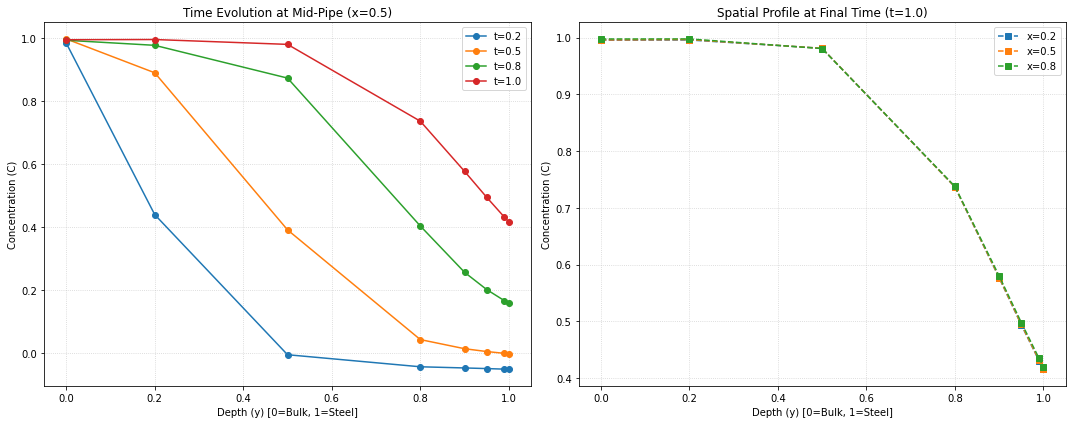

In [50]:
import matplotlib.pyplot as plt
import torch

# ==========================================
# DIAGNOSTIC BOUNDARY LAYER AUDIT (ORTHOGONAL SWEEPS)
# ==========================================
def diagnostic_boundary_scan_vmionet(model, data_tensors, device="cuda"):
    model.eval()
    x_soil, x_fluid, x_meta, _ = [t.to(device) for t in data_tensors]
    soil_single, fluid_single, meta_single = x_soil[0:1], x_fluid[0:1], x_meta[0:1]
    
    y_probes = [0.0, 0.2, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. TIME EVOLUTION SWEEP (Fixed x=0.5, Varying t)
    print("\n" + "="*50)
    print(" SWEEP 1: TIME EVOLUTION (Fixed x=0.5)")
    print("="*50)
    t_steps = [0.2, 0.5, 0.8, 1.0]
    
    for t_val in t_steps:
        C_vals, phi_vals = [], []
        with torch.no_grad():
            for y_val in y_probes:
                coord = torch.tensor([[[0.5, y_val, t_val]]], dtype=torch.float32, device=device)
                u_pred = model(soil_single, fluid_single, meta_single, coord)
                C_vals.append(u_pred[0, 0, 0].item())
                phi_vals.append(u_pred[0, 0, 1].item())
                
        print(f"t={t_val:<4} | C_wall: {C_vals[-1]:<12.6f} | phi_wall: {phi_vals[-1]:<12.6f}")
        
        ax1.plot(y_probes, C_vals, marker='o', label=f"t={t_val}")
    
    ax1.set_xlabel('Depth (y) [0=Bulk, 1=Steel]')
    ax1.set_ylabel('Concentration (C)')
    ax1.set_title('Time Evolution at Mid-Pipe (x=0.5)')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()

    # 2. SPATIAL DISTRIBUTION SWEEP (Fixed t=1.0, Varying x)
    print("\n" + "="*50)
    print(" SWEEP 2: SPATIAL DISTRIBUTION (Fixed t=1.0)")
    print("="*50)
    x_steps = [0.2, 0.5, 0.8]
    
    for x_val in x_steps:
        C_vals, phi_vals = [], []
        with torch.no_grad():
            for y_val in y_probes:
                coord = torch.tensor([[[x_val, y_val, 1.0]]], dtype=torch.float32, device=device)
                u_pred = model(soil_single, fluid_single, meta_single, coord)
                C_vals.append(u_pred[0, 0, 0].item())
                phi_vals.append(u_pred[0, 0, 1].item())
                
        print(f"x={x_val:<4} | C_wall: {C_vals[-1]:<12.6f} | phi_wall: {phi_vals[-1]:<12.6f}")
        
        ax2.plot(y_probes, C_vals, marker='s', linestyle='--', label=f"x={x_val}")

    ax2.set_xlabel('Depth (y) [0=Bulk, 1=Steel]')
    ax2.set_ylabel('Concentration (C)')
    ax2.set_title('Spatial Profile at Final Time (t=1.0)')
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# Trigger scan
diagnostic_boundary_scan_vmionet(trained_vmionet, dataset_tensors, execution_device)

In [51]:
import torch
import numpy as np

# ==========================================
# PINN VS FDM GROUND TRUTH VALIDATION
# ==========================================
def validate_pinn_vs_fdm(model, data_tensors, device="cuda"):
    try:
        # Load FDM Arrays
        C_history_fdm = np.load("fdm_C_history_v21.npy")
        phi_fdm_field = np.load("fdm_phi_field_v21.npy")
        y_grid_fdm = np.load("fdm_y_grid_v21.npy")
    except FileNotFoundError:
        print("ERROR: FDM .npy files not found. Make sure they are in the working directory.")
        return

    # Extract final timestep (t=1.0) for C
    C_fdm_final = C_history_fdm[-1] # Shape: [Nx, Ny]
    
    Nx, Ny = 21, 61
    x_grid_fdm = np.linspace(0.0, 1.0, Nx)
    
    # Build identically-spaced 3D coordinate tensor for the PINN
    X, Y = np.meshgrid(x_grid_fdm, y_grid_fdm, indexing='ij')
    T = np.ones_like(X) # t = 1.0
    
    pts_3d = np.stack([X.flatten(), Y.flatten(), T.flatten()], axis=-1)
    coords = torch.tensor(pts_3d, dtype=torch.float32, device=device).unsqueeze(0) 
    
    # Extract the first profile's environmental data
    x_soil, x_fluid, x_meta, _ = [t.to(device) for t in data_tensors]
    b_soil, b_fluid, b_meta = x_soil[0:1], x_fluid[0:1], x_meta[0:1]
    
    # Execute PINN Inference
    model.eval()
    with torch.no_grad():
        u_pred = model(b_soil, b_fluid, b_meta, coords)
        C_pinn_flat = u_pred[0, :, 0].cpu().numpy()
        phi_pinn_flat = u_pred[0, :, 1].cpu().numpy()
        
    C_pinn_final = C_pinn_flat.reshape(Nx, Ny)
    phi_pinn_field = phi_pinn_flat.reshape(Nx, Ny)
    
    # Calculate Relative L2 Errors
    C_err_l2 = np.linalg.norm(C_pinn_final - C_fdm_final) / (np.linalg.norm(C_fdm_final) + 1e-12)
    phi_err_l2 = np.linalg.norm(phi_pinn_field - phi_fdm_field) / (np.linalg.norm(phi_fdm_field) + 1e-12)
    
    print("\n" + "="*50)
    print(" PINN vs. FDM METRICS (t=1.0)")
    print("="*50)
    print(f"Concentration (C) Relative L2 Error : {C_err_l2:.4e}")
    print(f"Potential (phi) Relative L2 Error   : {phi_err_l2:.4e}")
    
    # Pointwise Comparison at mid-pipe wall (x=0.5, y=1.0)
    mid_x_idx = Nx // 2
    wall_y_idx = Ny - 1
    
    print("\n--- Mid-Pipe Wall Point (x=0.5, y=1.0) ---")
    print(f"{'Metric':<10} | {'PINN':<15} | {'FDM':<15}")
    print("-" * 45)
    print(f"{'C_wall':<10} | {C_pinn_final[mid_x_idx, wall_y_idx]:<15.8e} | {C_fdm_final[mid_x_idx, wall_y_idx]:<15.8e}")
    print(f"{'phi_wall':<10} | {phi_pinn_field[mid_x_idx, wall_y_idx]:<15.8e} | {phi_fdm_field[mid_x_idx, wall_y_idx]:<15.8e}")
    print("-" * 45)

# Trigger validation
validate_pinn_vs_fdm(trained_vmionet, dataset_tensors, execution_device)


 PINN vs. FDM METRICS (t=1.0)
Concentration (C) Relative L2 Error : 1.6058e+00
Potential (phi) Relative L2 Error   : 1.3817e+02

--- Mid-Pipe Wall Point (x=0.5, y=1.0) ---
Metric     | PINN            | FDM            
---------------------------------------------
C_wall     | 4.16477054e-01  | 1.44851037e-06 
phi_wall   | 2.77407020e-01  | -1.92969720e-03
---------------------------------------------
